## Generate Training Spectra


In [ ]:
import gc
import os
import re
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import multirex as mrex
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def remove_warnings() -> None:
    """Suppress deprecation warnings produced by external dependencies."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


waves = np.loadtxt("waves.txt")
n_points = len(waves)

# Keep the original full-grid wavelength selection explicitly visible.
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)
waves = waves[indices]

# Wavenumber grid used by downstream spectral operations.
wn_grid = np.sort(10000 / waves)



def attach_spectrum_blocks(df, n_data_columns):
    """Attach local `.data` and `.params` views used by this notebook."""
    object.__setattr__(df, "data", df.iloc[:, -n_data_columns:])
    object.__setattr__(df, "params", df.iloc[:, :-n_data_columns])
    return df


## Load Spectral Data


In [ ]:
def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Apply multiple contaminations to a DataFrame using a list of contamination files.

    The output includes:
    - A non-contaminated case (f_spot = 0.0, f_fac = 0.0)
    - One contaminated copy per file, where the last `n_points` columns are scaled
      by the contamination vector read from that file.

    The file name is expected to encode parameters using:
        fspot<value>_ffac<value>.txt

    Parameters
    ----------
    contamination_files : list of str
        Paths to `.txt` files containing contamination vectors.
    df : pandas.DataFrame
        Original DataFrame to which contaminations will be applied.
    n_points : int
        Number of trailing columns to scale by the contamination vector.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame including the non-contaminated case and all
        contaminations. Three columns are prepended: `contam_source`, `f_spot`,
        and `f_fac`.

    Notes
    -----
    This function attaches two convenience attributes to the returned DataFrame:
    - `df_final.data`: last `n_points` columns
    - `df_final.params`: all other columns
    """
    df_list = []

    # --- Non-contaminated case ---
    df_no_contam = df.copy()
    df_no_contam["contam_source"] = "clean"
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0

    cols = ["contam_source", "f_spot", "f_fac"] + [
        col
        for col in df_no_contam.columns
        if col not in ["contam_source", "f_spot", "f_fac"]
    ]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file '{file_path}' does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(
                f"The file name '{filename}' does not match the expected pattern "
                f"'fspot<value>_ffac<value>.txt'."
            )

        contam_source = "sphinx" if filename.startswith("sphinx_") else "original"
        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' "
                    f"({len(contam_values)}) does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file '{file_path}': {e}") from e

        contam_values = contam_values[::-1]

        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(
            contam_values, axis=1
        )

        df_contam["contam_source"] = contam_source
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    df_final = pd.concat(df_list, ignore_index=True)

    return attach_spectrum_blocks(df_final, n_points)


In [ ]:
contamination_dir = "stellar_contamination"
contamination_files = [
    os.path.join(contamination_dir, filename).replace("\\", "/")
    for filename in sorted(
        os.listdir(contamination_dir), key=lambda name: (name.startswith("sphinx_"), name)
    )
    if filename.endswith(".txt") and "TRAPPIST-1_contam_fspot" in filename
]


def filter_rows(df):
    """
    Filter rows where at least one of the target atmospheric columns is >= -8.

    If none of the target columns exist, the DataFrame is returned unchanged.

    Notes
    -----
    This function preserves the original behavior of sequential filtering when
    multiple columns are present (each filter is applied on the result of the
    previous one).
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]

    return attach_spectrum_blocks(df, n_points)


remove_warnings()

datasets = [
    ("airless_data", "spec_data/airless_data.csv", False),
    ("CO2_data", "spec_data/CO2_data.csv", False),
    ("CH4_data", "spec_data/CH4_data.csv", True),
    ("O3_data", "spec_data/O3_data.csv", True),
    ("H2O_data", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = apply_contaminations_from_files(contamination_files, df, n_points)
        globals()[name] = df  # Keep the original variable names in the notebook.
    except Exception as e:
        print(f"Error processing {name}: {e}")

In [ ]:
def normalize_min_max_by_row(df):
    """Normalize each spectrum independently to the [0, 1] range."""
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    normalized[range_by_row == 0] = 0
    return normalized


## Build Clean Reference Data


In [ ]:
def mult_df(df, n_points, n_mult):
    """
    Duplicate a DataFrame `n_mult + 1` times and prepend contamination parameters.

    Each duplicate is a copy of `df` with two added columns:
    - 'f_spot' = 0.0
    - 'f_fac' = 0.0

    The returned DataFrame also exposes two convenience attributes:
    - `.data`: last `n_points` columns
    - `.params`: all remaining columns

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame to duplicate.
    n_points : int
        Number of trailing columns treated as the "data" block.
    n_mult : int
        Number of extra duplicates; total copies will be `n_mult + 1`.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame with `n_mult + 1` copies and 'f_spot'/'f_fac'
        columns placed first.
    """
    df_list = []

    for _ in range(n_mult + 1):
        df_no_contam = df.copy()
        df_no_contam["contam_source"] = "clean"
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0

        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_no_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    return attach_spectrum_blocks(df_final, n_points)


In [ ]:
datasets_clean = [
    ("airless_data_clean", "spec_data/airless_data.csv", False),
    ("CO2_data_clean", "spec_data/CO2_data.csv", False),
    ("CH4_data_clean", "spec_data/CH4_data.csv", True),
    ("O3_data_clean", "spec_data/O3_data.csv", True),
    ("H2O_data_clean", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data_clean", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data_clean", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data_clean", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data_clean", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets_clean:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = mult_df(df, n_points, len(contamination_files))
        globals()[name] = df
    except Exception as e:
        print(f"Error processing {name}: {e}")


# Add Instrumental Noise

The following cells build paired noisy and clean datasets for each S/N level.


In [ ]:
def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """Repeat spectra and add Gaussian noise with scalar or per-row noise levels."""
    if n_repeat <= 0:
        raise ValueError("n_repeat must be positive.")

    if seed is not None:
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data

    spectra_repeated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns,
    )

    if np.isscalar(noise_std):
        if noise_std < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_repeated = np.full(spectra_repeated.shape, noise_std)
        noise_column = noise_std
    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if len(noise_array) != len(df_spectra):
            raise ValueError("noise_std must match the number of input spectra.")
        if np.any(noise_array < 0):
            raise ValueError("noise_std values must be non-negative.")

        noise_repeated = np.repeat(noise_array[:, None], n_repeat, axis=0)
        noise_repeated = np.tile(noise_repeated, (1, spectra_repeated.shape[1]))
        noise_column = np.repeat(noise_array, n_repeat)

    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_repeated,
        size=spectra_repeated.shape,
    )
    spectra_repeated += gaussian_noise

    params_repeated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns,
    )
    params_repeated.insert(0, "noise_std", noise_column)
    params_repeated.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [params_repeated.reset_index(drop=True), spectra_repeated.reset_index(drop=True)],
        axis=1,
    )

    return attach_spectrum_blocks(df_final, spectra_repeated.shape[1])


## S/N = 1


In [ ]:
DATASET_ORDER = [
    "CO2",
    "CH4",
    "O3",
    "H2O",
    "CH4_O3",
    "CH4_H2O",
    "O3_H2O",
    "CH4_O3_H2O",
    "airless",
]

SPECTRAL_DATASETS = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

CLEAN_DATASETS = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

REPEAT_COUNTS = {
    1: {
        "CO2": 3_000,
        "CH4": 300,
        "O3": 300,
        "H2O": 300,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 3_000,
    },
    3: {
        "CO2": 3_000,
        "CH4": 300,
        "O3": 300,
        "H2O": 300,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 3_000,
    },
    6: {
        "CO2": 2_500,
        "CH4": 250,
        "O3": 250,
        "H2O": 250,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 2_500,
    },
    10: {
        "CO2": 2_000,
        "CH4": 200,
        "O3": 200,
        "H2O": 200,
        "CH4_O3": 20,
        "CH4_H2O": 20,
        "O3_H2O": 20,
        "CH4_O3_H2O": 5,
        "airless": 2_000,
    },
    "noiseless": {
        "CO2": 5_000,
        "CH4": 500,
        "O3": 500,
        "H2O": 500,
        "CH4_O3": 50,
        "CH4_H2O": 50,
        "O3_H2O": 50,
        "CH4_O3_H2O": 7,
        "airless": 4_000,
    },
}


def build_snr_pair(snr, repeat_counts):
    """Build matched noisy and clean DataFrames for one S/N setting."""
    noise_std = 0 if snr is None else mrex.generate_df_SNR_noise(
        df=CO2_data,
        n_repeat=1,
        SNR=snr,
    )["noise"][1]

    noisy_parts = [
        generate_df_with_noise_std(
            df=SPECTRAL_DATASETS[key],
            n_repeat=repeat_counts[key],
            noise_std=noise_std,
        )
        for key in DATASET_ORDER
    ]
    noisy_df = pd.concat(noisy_parts, ignore_index=True)
    noisy_df = attach_spectrum_blocks(noisy_df, n_points)

    clean_parts = [
        generate_df_with_noise_std(
            df=CLEAN_DATASETS[key],
            n_repeat=repeat_counts[key],
            noise_std=0,
        )
        for key in DATASET_ORDER
    ]
    clean_df = pd.concat(clean_parts, ignore_index=True)
    clean_df = attach_spectrum_blocks(clean_df, n_points)

    del noisy_parts, clean_parts
    gc.collect()

    print("Clean and noisy dataframes have the same shape:", noisy_df.shape == clean_df.shape)
    return noisy_df, clean_df


SNR1_df, SNR1_no_df = build_snr_pair(1, REPEAT_COUNTS[1])


## S/N = 3


In [ ]:
SNR3_df, SNR3_no_df = build_snr_pair(3, REPEAT_COUNTS[3])


## S/N = 6


In [ ]:
SNR6_df, SNR6_no_df = build_snr_pair(6, REPEAT_COUNTS[6])


## S/N = 10


In [ ]:
SNR10_df, SNR10_no_df = build_snr_pair(10, REPEAT_COUNTS[10])


## Noiseless Reference


In [ ]:
SNRNan_df, SNRNan_no_df = build_snr_pair(None, REPEAT_COUNTS["noiseless"])


## Assemble Training Arrays


In [ ]:
# Combine all noisy datasets and normalize the spectral block.
SNRall_noisy = pd.concat(
    [SNR1_df, SNR3_df, SNR6_df, SNR10_df, SNRNan_df], ignore_index=True
)

del SNR1_df, SNR3_df, SNR6_df, SNR10_df, SNRNan_df
gc.collect()

SNRall_noisy.iloc[:, -n_points:] = normalize_min_max_by_row(
    SNRall_noisy.iloc[:, -n_points:]
)
X_noisy = SNRall_noisy.iloc[:, -n_points:].values

# Combine the clean counterparts in the same order and normalize them.
SNRall_no_noisy = pd.concat(
    [SNR1_no_df, SNR3_no_df, SNR6_no_df, SNR10_no_df, SNRNan_no_df], ignore_index=True
)

del SNR1_no_df, SNR3_no_df, SNR6_no_df, SNR10_no_df, SNRNan_no_df
gc.collect()

SNRall_no_noisy.iloc[:, -n_points:] = normalize_min_max_by_row(
    SNRall_no_noisy.iloc[:, -n_points:]
)
X_no_noisy = SNRall_no_noisy.iloc[:, -n_points:].values

assert SNRall_noisy.shape[0] == SNRall_no_noisy.shape[0], (
    "The number of samples does not match between X_noisy and X_clean."
)

del SNRall_noisy, SNRall_no_noisy
gc.collect()


### Final Training Data


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [15]:
test_size = 0.2

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_no_noisy,
    test_size=test_size,
)

del X_noisy, X_no_noisy
gc.collect()


0

In [17]:
len(X_train_noisy) +  len(X_test_noisy)

5905960

### Autoencoder


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

input_dim = X_train_noisy.shape[1]
l2_lambda = 1e-7

assert input_dim in {n_points, 2 * n_points}, (
    f"Unexpected input_dim={input_dim}. Expected n_points={n_points} "
    f"or 2*n_points={2 * n_points}."
)

input_spectrum = keras.Input(shape=(input_dim,))

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

output = layers.Dense(n_points, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_spectrum, outputs=output)

optimizer = Adam(learning_rate=1e-5)
autoencoder.compile(optimizer=optimizer, loss="mae")

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 385)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 385)            │       197,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,673 (7.72 MB)

 Trainable params: 2,024,673 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 851s 11ms/step - loss: 0.0316 - val_loss: 0.0202
Epoch 2/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 831s 11ms/step - loss: 0.0314 - val_loss: 0.0202
Epoch 3/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 834s 11ms/step - loss: 0.0312 - val_loss: 0.0200
Epoch 4/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 843s 11ms/step - loss: 0.0311 - val_loss: 0.0200
Epoch 5/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 851s 12ms/step - loss: 0.0309 - val_loss: 0.0199
Epoch 6/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 867s 12ms/step - loss: 0.0308 - val_loss: 0.0198
Epoch 7/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 869s 12ms/step - loss: 0.0307 - val_loss: 0.0197
Epoch 8/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 876s 12ms/step - loss: 0.0306 - val_loss: 0.0195
Epoch 9/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 875s 12ms/step - loss: 0.0304 - val_loss: 0.0195
Epoch 10/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 875s 12ms/step - loss: 0.0304 - val_loss: 0.0194
Epoch 11/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 880s 12ms/ste

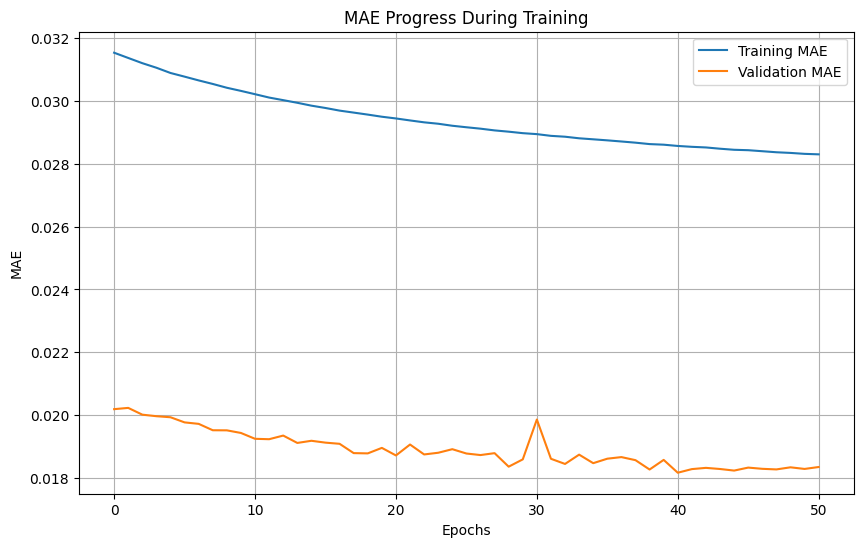

36913/36913 ━━━━━━━━━━━━━━━━━━━━ 253s 7ms/step


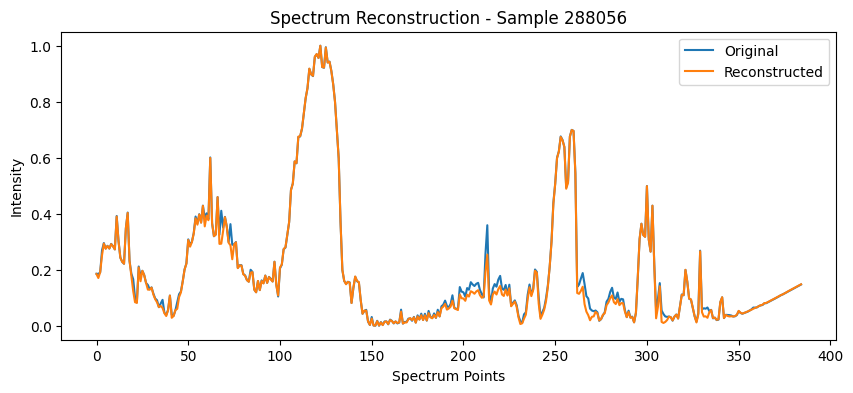

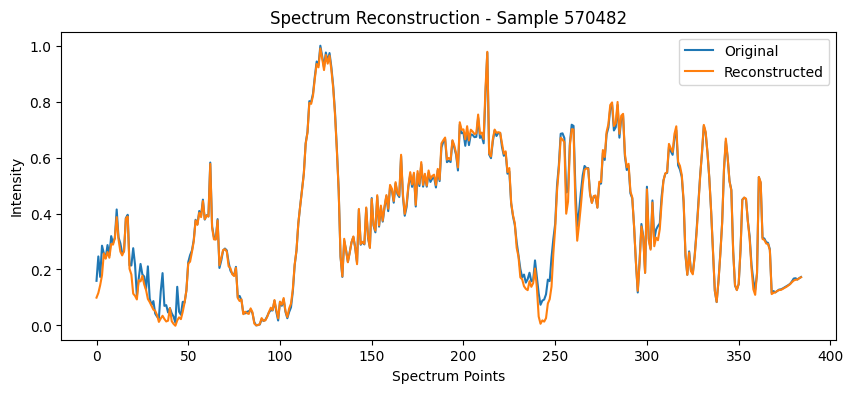

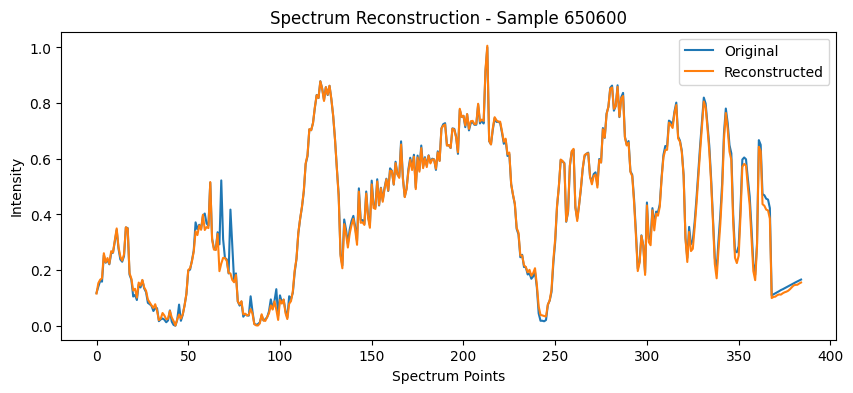

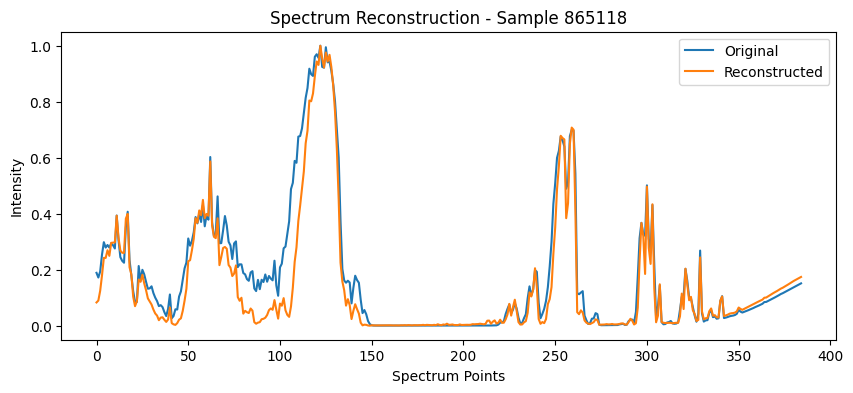

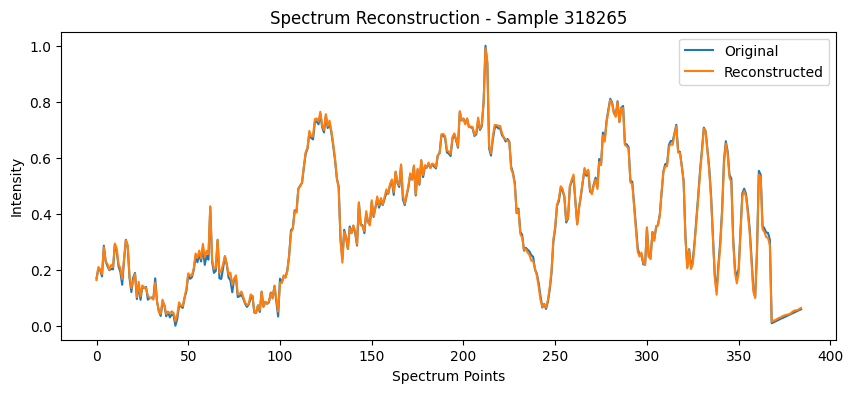

In [21]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train_clean,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_clean),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
)

# Save the trained model
autoencoder.save("Models/G-DAE.keras")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.title("MAE Progress During Training")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# Predict reconstructed spectra on test data
decoded_spectra = autoencoder.predict(X_test_noisy)

# Visualize a few reconstructions
num_samples = 5  # Number of samples to visualize
indices = np.random.choice(len(X_test_noisy), num_samples, replace=False)

for idx in indices:
    plt.figure(figsize=(10, 4))
    plt.plot(X_test_clean[idx].flatten(), label="Original")
    plt.plot(decoded_spectra[idx].flatten(), label="Reconstructed")
    plt.xlabel("Spectrum Points")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum Reconstruction - Sample {idx}")
    plt.legend()
    plt.show()


# Evaluation


In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

# Load the trained autoencoder model and reconstruct the test spectra
autoencoder = keras.models.load_model("Models/G-DAE.keras")

X_reconstructed = autoencoder.predict(X_test_noisy)

# Compute evaluation metrics on the test set
mae = mean_absolute_error(X_test_clean, X_reconstructed)
print(f"Mean Absolute Error (MAE): {mae:.6f}")

mse = mean_squared_error(X_test_clean, X_reconstructed)
print(f"Mean Squared Error (MSE): {mse:.6f}")

r2 = r2_score(X_test_clean, X_reconstructed)
print(f"Coefficient of Determination (R²): {r2:.6f}")

36913/36913 ━━━━━━━━━━━━━━━━━━━━ 241s 7ms/step
Mean Absolute Error (MAE): 0.017703
Mean Squared Error (MSE): 0.002592
Coefficient of Determination (R²): 0.909032


## Reconstruction Plot


In [ ]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR=3     
)["noise"][1]


SNR3_CO2_data = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat=10_000,
    noise_std = noise     
)

SNR3_CH4_data = generate_df_with_noise_std(
    df=CH4_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_O3_data = generate_df_with_noise_std(
    df=O3_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_H2O_data = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_CH4_O3_data = generate_df_with_noise_std(
    df=CH4_O3_data,
    n_repeat=350, # 350 for graph
    noise_std = noise
)

SNR3_CH4_H2O_data = generate_df_with_noise_std(
    df=CH4_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_O3_H2O_data = generate_df_with_noise_std(
    df=O3_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_CH4_O3_H2O_data = generate_df_with_noise_std(
    df=CH4_O3_H2O_data,
    n_repeat=5,
    noise_std = noise
)
    
SNR3_airless_data = generate_df_with_noise_std(
    df=airless_data,
    n_repeat=10_000,
    noise_std = noise   
)

SNR3_df = pd.concat(
    [
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
    ],
    ignore_index=True
) 


del (
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
        
)

gc.collect()


In [ ]:
# Display the first few rows (for quick sanity check).
SNR3_df.head()

# Filter the DataFrame for a specific stellar contamination configuration.
target_contam_source = "original"
auto_SNR3_df = SNR3_df[
    (SNR3_df["contam_source"] == target_contam_source)
    & (SNR3_df["f_spot"] == 0.08)
    & (SNR3_df["f_fac"] == 0.54)
].copy()

# Normalize the spectral block (last n_points columns) row-wise.
auto_SNR3_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    auto_SNR3_df.iloc[:, -n_points:]
)

# Predict the encoded representation (assumes `autoencoder` is already defined/loaded).
X = auto_SNR3_df.iloc[:, -n_points:].values
X = autoencoder.predict(X)

# Store the encoded output back into a copy of the original DataFrame.
auto_reconstructed_SNR3_df = auto_SNR3_df.copy()
auto_reconstructed_SNR3_df.iloc[:, -n_points:] = X

# Non-atmospheric CO2 example (atm CO2 == 0).
airless_SNR3 = auto_SNR3_df[auto_SNR3_df["atm CO2"] == 0].iloc[1, -n_points:].values
airless_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    auto_reconstructed_SNR3_df["atm CO2"] == 0
].iloc[1, -n_points:].values

# Clean reference for the airless case.
airless_clean_df = airless_data[airless_data["f_spot"] == 0.0].copy()
airless_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    airless_clean_df.iloc[:, -n_points:]
)
airless_clean = airless_clean_df.iloc[0, -n_points:].values

# CO2 analysis: select a row index `i` under CH4=O3=H2O=0.
i = 96
print(f"CO2 = {i}")

CO2_SNR3_df = auto_SNR3_df[
    (auto_SNR3_df["atm CH4"] == 0)
    & (auto_SNR3_df["atm O3"] == 0)
    & (auto_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:].values

CO2_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    (auto_reconstructed_SNR3_df["atm CH4"] == 0)
    & (auto_reconstructed_SNR3_df["atm O3"] == 0)
    & (auto_reconstructed_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:].values

CO2_clean_df = CO2_data[CO2_data["f_spot"] == 0.0].copy()
CO2_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    CO2_clean_df.iloc[:, -n_points:]
)
CO2_clean = CO2_clean_df.iloc[1, -n_points:].values

# Biosignature analysis: select a row index `i` for specific CH4/O3/H2O values.
i = 185
print(f"bio = {i}")

bio_SNR3_df = auto_SNR3_df[
    (auto_SNR3_df["atm CH4"] == -5)
    & (auto_SNR3_df["atm O3"] == -7)
    & (auto_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:]

bio_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    (auto_reconstructed_SNR3_df["atm CH4"] == -5)
    & (auto_reconstructed_SNR3_df["atm O3"] == -7)
    & (auto_reconstructed_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:]

bio_clean_df = CH4_O3_data[
    (CH4_O3_data["f_spot"] == 0.0)
    & (CH4_O3_data["f_fac"] == 0.0)
    & (CH4_O3_data["atm CH4"] == -5)
    & (CH4_O3_data["atm O3"] == -7)
    & (CH4_O3_data["atm H2O"] == 0)
].copy()
bio_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    bio_clean_df.iloc[:, -n_points:]
)
bio_clean = bio_clean_df.iloc[1, -n_points:].values

X_clean = [airless_clean, CO2_clean, bio_clean]
X_noisy = [airless_SNR3, CO2_SNR3_df, bio_SNR3_df]
X_reconstructed = [
    airless_reconstructed_SNR3,
    CO2_reconstructed_SNR3,
    bio_reconstructed_SNR3,
]


4513/4513 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step
CO2 = 96
bio = 185


In [ ]:
import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

' \nplt.savefig("plots/autoencoder.svg", format="svg", dpi=500)\nplt.savefig("plots/autoencoder.pdf", format="pdf", dpi=500)\nplt.show() '

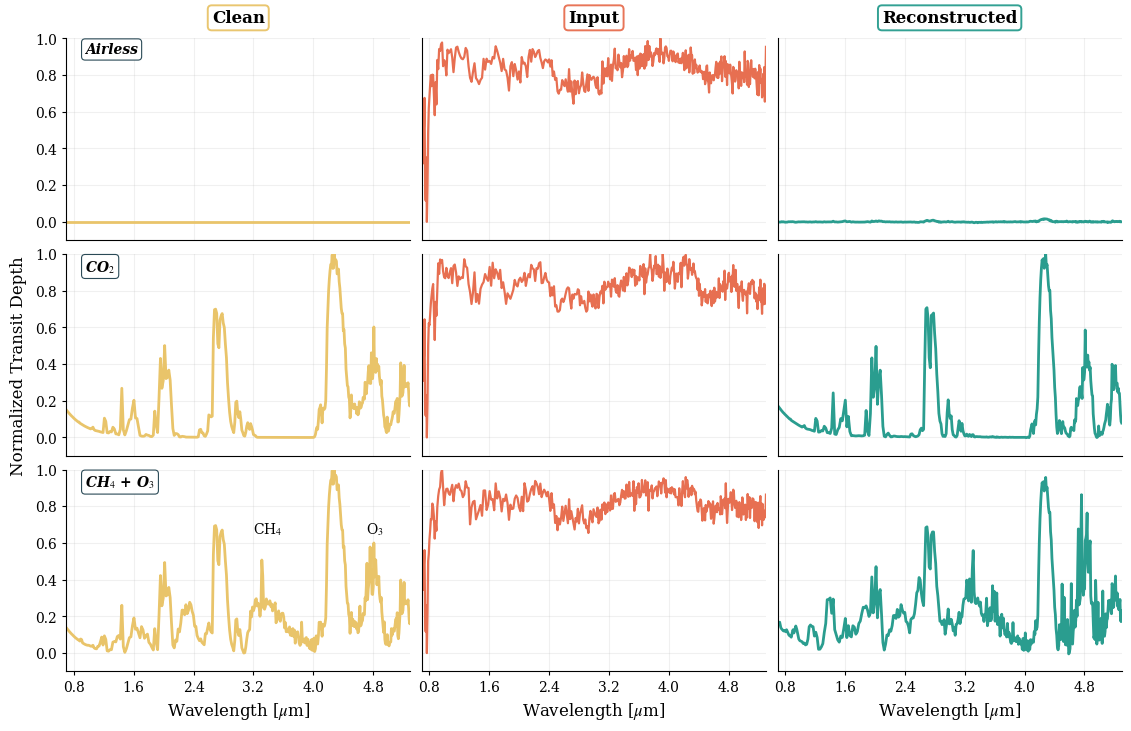

In [ ]:
PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",  # Reconstructed
    "sand": "#E9C46A",  # Clean
    "apricot": "#F4A261",
    "tomato": "#E76F51",  # Input
}

clean_color = PALETTE["sand"]
input_color = PALETTE["tomato"]
reconstructed_color = PALETTE["teal"]

X_clean = np.asarray(X_clean, dtype=object)
X_noisy = np.asarray(X_noisy, dtype=object)
X_reconstructed = np.asarray(X_reconstructed, dtype=object)
waves = np.asarray(waves)

num_samples = 3
indices = [0, 1, 2]
row_labels = ["Airless", r"CO$_2$", r"CH$_4$ + O$_3$"]
col_labels = ["Uncontaminated", "Input", "Reconstructed"]
title_colors = [clean_color, input_color, reconstructed_color]

x = waves[::-1]


def _style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.grid(True, axis="both", alpha=0.18, linewidth=0.8)
    ax.margins(x=0)


def _boxed_col_title(ax, text, edge_color):
    ax.text(
        0.5,
        1.06,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.24",
            fc="white",
            ec=edge_color,
            lw=1.4,
            alpha=0.96,
        ),
        clip_on=False,
    )


fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(11.2, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for j in range(3):
    _boxed_col_title(axes[0, j], col_labels[j], title_colors[j])

for i, idx in enumerate(indices):
    axes[i, 0].plot(x, X_clean[idx], color=clean_color, lw=2.0)
    axes[i, 1].plot(x, X_noisy[idx], color=input_color, lw=1.6)
    axes[i, 2].plot(x, X_reconstructed[idx], color=reconstructed_color, lw=2.0)

    for j in range(3):
        _style_axis(axes[i, j])
        axes[i, j].set_ylim(-0.1, 1.0)

    row_badge_x = 0.055
    axes[i, 0].text(
        row_badge_x,
        0.98,
        row_labels[i],
        transform=axes[i, 0].transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontstyle="italic",
        fontweight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.26",
            fc="white",
            ec=PALETTE["ink"],
            lw=0.8,
            alpha=0.98,
        ),
    )

    if i == 2:
        axes[i, 0].text(3.2, 0.65, r"CH$_4$", fontsize=10, color="black")
        axes[i, 0].text(4.7, 0.65, r"O$_3$", fontsize=10, color="black")

    if i < num_samples - 1:
        for j in range(3):
            axes[i, j].tick_params(bottom=False, labelbottom=False)

for j in (1, 2):
    for i in range(num_samples):
        axes[i, j].tick_params(left=False, labelleft=False)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wavelength [$\mu$m]", fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

try:
    fig.supylabel("Normalized Transit Depth", fontsize=12)
except AttributeError:
    fig.text(
        0.03,
        0.5,
        "Normalized Transit Depth",
        rotation="vertical",
        va="center",
        ha="center",
        fontsize=12,
    )
""" 
plt.savefig("plots/autoencoder.svg", format="svg", dpi=500)
plt.savefig("plots/autoencoder.pdf", format="pdf", dpi=500)
plt.show() """